## 1. Setup and Imports

In [2]:
import sys
import os

# Add parent directory to path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.pipeline.customer_segmentation import CustomerSegmentation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports successful!")

✅ Imports successful!


## 2. Run Customer Segmentation Pipeline

In [3]:
# Initialize and run pipeline
segmentation = CustomerSegmentation()
success = segmentation.run_pipeline()

🚀 CUSTOMER SEGMENTATION PIPELINE
🔗 Connecting to database...
✅ Connected successfully!

📊 Extracting RFM data from warehouse...
✅ Extracted 96478 customers
📋 Columns: ['customer_sk', 'customer_unique_id', 'customer_state', 'customer_city', 'customer_region', 'recency_days', 'frequency_orders', 'monetary_value', 'avg_order_value', 'total_freight', 'avg_freight_value', 'total_items_purchased', 'first_purchase_date', 'last_purchase_date', 'customer_lifetime_days', 'avg_review_score', 'total_reviews', 'purchase_frequency_rate']

🔧 Engineering features...
✅ Features engineered successfully

🎯 Preparing features for clustering...
✅ Prepared 96478 samples with 7 features

🔍 Finding optimal k (testing k=2 to k=8)...
  k=2: Inertia=308831.52, Silhouette=0.392
  k=3: Inertia=245690.02, Silhouette=0.405
  k=4: Inertia=189495.85, Silhouette=0.388
  k=5: Inertia=154593.95, Silhouette=0.390
  k=6: Inertia=139599.30, Silhouette=0.398
  k=7: Inertia=120431.41, Silhouette=0.398
  k=8: Inertia=107614.10

## 3. Load and Explore Results

In [27]:
# Load saved results
df_segments = pd.read_csv('../outputs/customer_segments.csv')

print(f"Total Customers: {len(df_segments):,}")
print(f"\nColumns: {list(df_segments.columns)}")
print(f"\nFirst 5 rows:")
df_segments.head()

Total Customers: 96,478

Columns: ['customer_sk', 'customer_unique_id', 'customer_state', 'customer_region', 'recency_days', 'frequency_orders', 'monetary_value', 'avg_order_value', 'avg_review_score', 'customer_lifetime_days', 'rfm_score', 'customer_value', 'kmeans_cluster', 'dbscan_cluster', 'segment_label', 'pca_1', 'pca_2']

First 5 rows:


,customer_sk,customer_unique_id,customer_state,customer_region,recency_days,frequency_orders,monetary_value,avg_order_value,avg_review_score,customer_lifetime_days,rfm_score,customer_value,kmeans_cluster,dbscan_cluster,segment_label,pca_1,pca_2
0,8547,0a0a92112bd4c708ca5fde585afaa872,RJ,Sudeste,2986.0,1,109312.64,1708.01,1.0,0.0,8,Medium Value,2,-1,😴 Lost Customers,129.793597,-1.128308
1,73859,698e1cf81d01a3d389d96145f7fa6df8,GO,Centro-Oeste,3023.0,1,45256.00,113.14,3.0,0.0,8,Medium Value,2,-1,😴 Lost Customers,51.180545,0.284738
2,74119,c402f431464c72e27330a67f7b94d4fb,SP,Sudeste,2840.0,1,44048.00,110.12,1.0,0.0,9,Medium Value,2,-1,😴 Lost Customers,50.014690,0.413367
3,2066,4007669dec559734d6f53e029e360987,MG,Sudeste,2930.0,1,36489.24,1013.59,1.0,0.0,8,Medium Value,2,-1,😴 Lost Customers,44.616782,0.525293
4,12399,ef8d54b3797ea4db1d63f0ced6a906e9,RJ,Sudeste,2784.0,1,30186.00,301.86,5.0,0.0,10,High Value,2,-1,😴 Lost Customers,34.522779,-1.687722


## 4. RFM Distribution Analysis

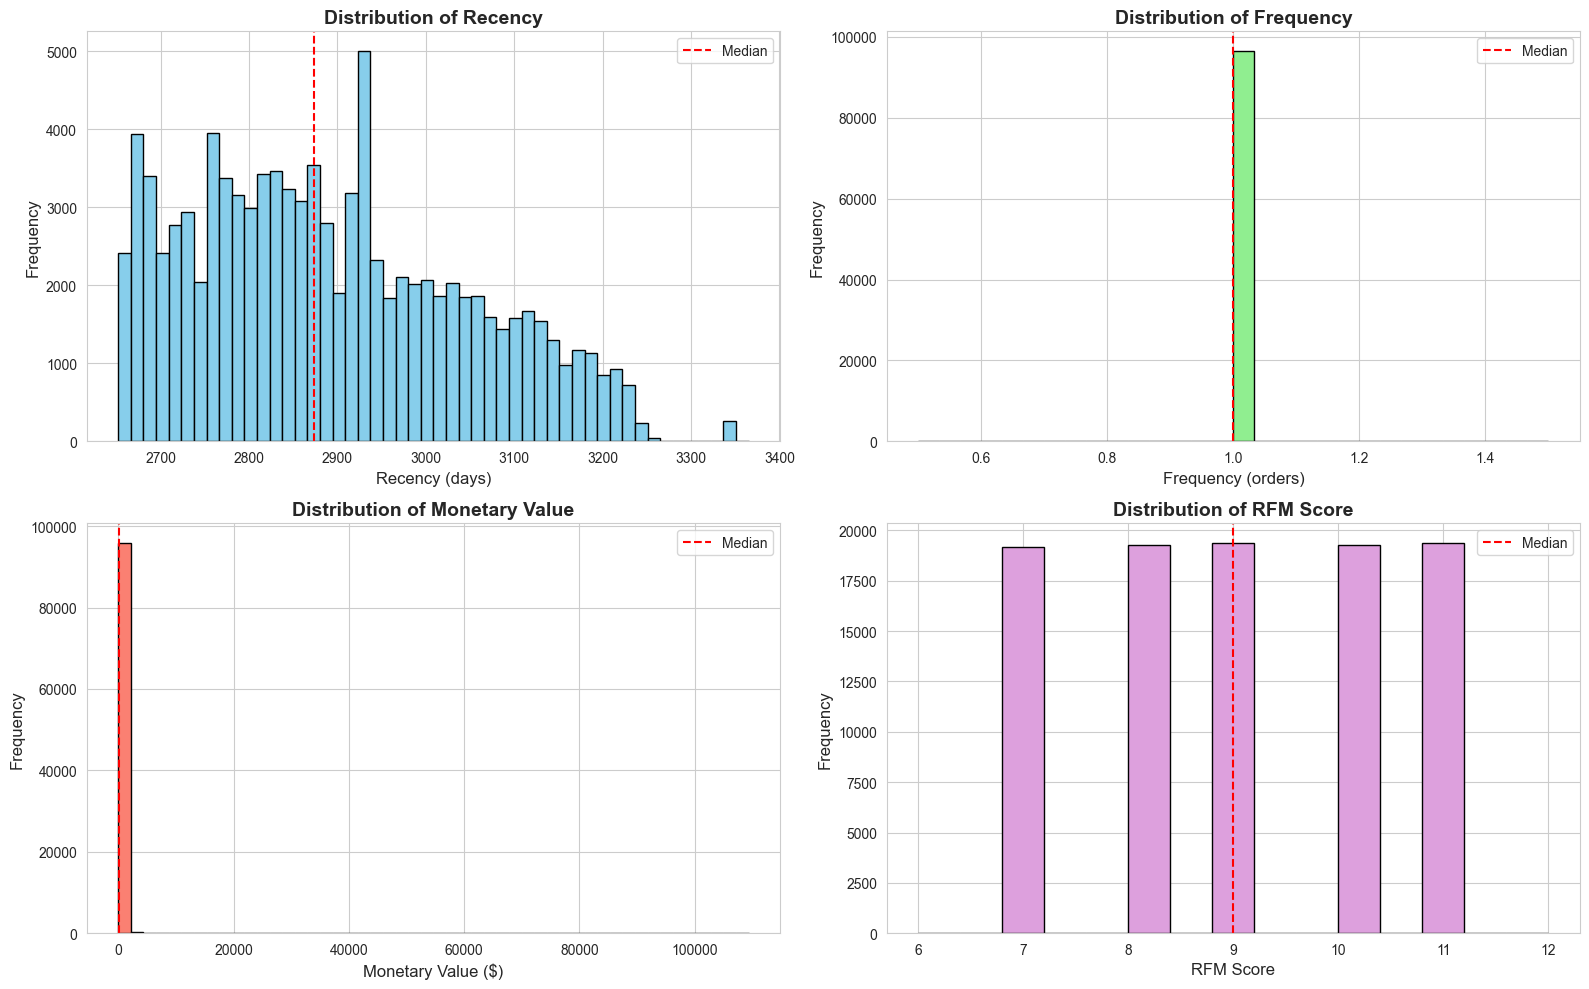

📊 RFM Statistics:
       recency_days  frequency_orders  monetary_value     rfm_score
count  96478.000000           96478.0    96478.000000  96478.000000
mean    2891.657570               1.0      204.982523      9.003763
std      152.840157               0.0      621.236470      1.413912
min     2652.000000               1.0        9.590000      6.000000
25%     2768.000000               1.0       62.662500      8.000000
50%     2873.000000               1.0      109.500000      9.000000
75%     3001.000000               1.0      195.530000     10.000000
max     3365.000000               1.0   109312.640000     12.000000


In [28]:
# Plot RFM distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Recency
axes[0, 0].hist(df_segments['recency_days'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Recency (days)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Recency', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df_segments['recency_days'].median(), color='red', linestyle='--', label='Median')
axes[0, 0].legend()

# Frequency
axes[0, 1].hist(df_segments['frequency_orders'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Frequency (orders)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Frequency', fontsize=14, fontweight='bold')
axes[0, 1].axvline(df_segments['frequency_orders'].median(), color='red', linestyle='--', label='Median')
axes[0, 1].legend()

# Monetary
axes[1, 0].hist(df_segments['monetary_value'], bins=50, color='salmon', edgecolor='black')
axes[1, 0].set_xlabel('Monetary Value ($)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Monetary Value', fontsize=14, fontweight='bold')
axes[1, 0].axvline(df_segments['monetary_value'].median(), color='red', linestyle='--', label='Median')
axes[1, 0].legend()

# RFM Score
axes[1, 1].hist(df_segments['rfm_score'], bins=15, color='plum', edgecolor='black')
axes[1, 1].set_xlabel('RFM Score', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Distribution of RFM Score', fontsize=14, fontweight='bold')
axes[1, 1].axvline(df_segments['rfm_score'].median(), color='red', linestyle='--', label='Median')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../outputs/rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 RFM Statistics:")
print(df_segments[['recency_days', 'frequency_orders', 'monetary_value', 'rfm_score']].describe())

## 5. Segment Distribution

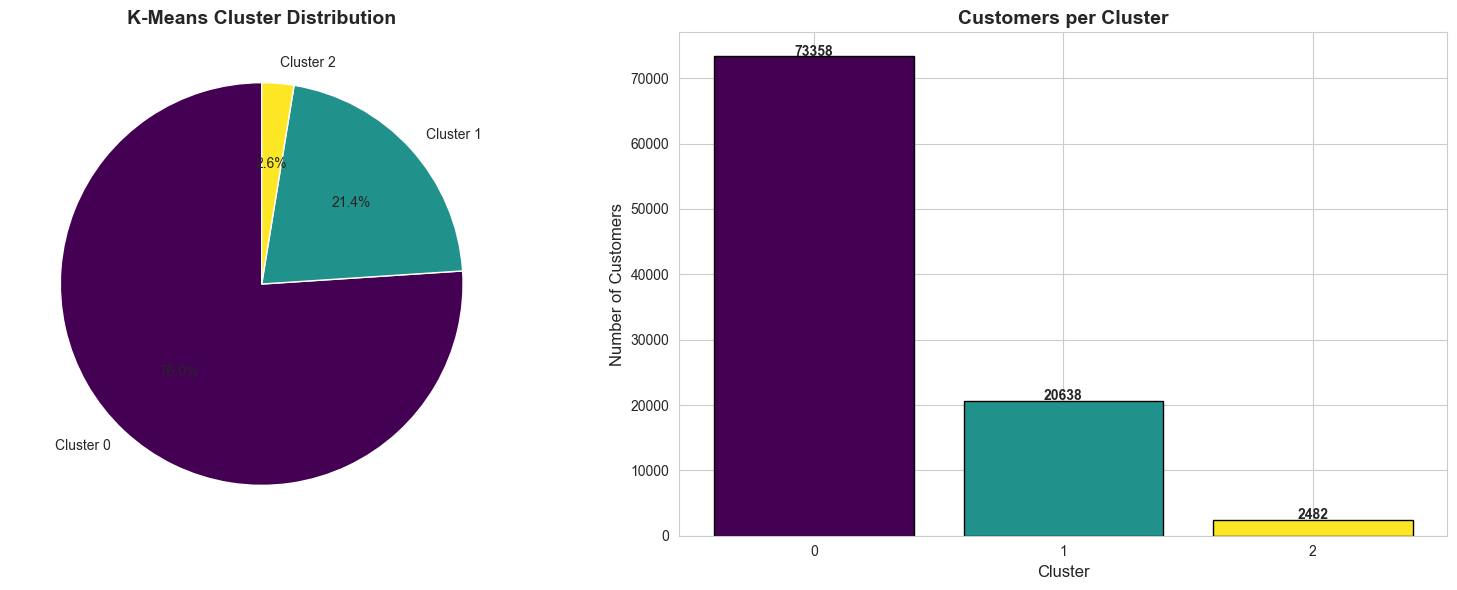

In [29]:
# K-Means cluster distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
cluster_counts = df_segments['kmeans_cluster'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_counts)))
axes[0].pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('K-Means Cluster Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].set_title('Customers per Cluster', fontsize=14, fontweight='bold')
axes[1].set_xticks(cluster_counts.index)

# Add value labels on bars
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Segment Characteristics - Detailed Analysis

In [30]:
# Detailed segment analysis
segment_profile = df_segments.groupby('kmeans_cluster').agg({
    'customer_sk': 'count',
    'recency_days': ['mean', 'median'],
    'frequency_orders': ['mean', 'median'],
    'monetary_value': ['mean', 'median', 'sum'],
    'avg_order_value': 'mean',
    'avg_review_score': 'mean',
    'customer_lifetime_days': 'mean'
}).round(2)

segment_profile.columns = ['_'.join(col).strip() for col in segment_profile.columns.values]
segment_profile = segment_profile.rename(columns={'customer_sk_count': 'Total_Customers'})

print("\n📊 Detailed Segment Profile:")
print(segment_profile.to_string())


📊 Detailed Segment Profile:
                Total_Customers  recency_days_mean  recency_days_median  frequency_orders_mean  frequency_orders_median  monetary_value_mean  monetary_value_median  monetary_value_sum  avg_order_value_mean  avg_review_score_mean  customer_lifetime_days_mean
kmeans_cluster                                                                                                                                                                                                                                                   
0                         73358            2890.33               2873.0                    1.0                      1.0               154.00                 103.93         11296919.52                121.80                   4.75                          0.0
1                         20638            2895.72               2872.0                    1.0                      1.0               204.19                 116.94          4214041.55              

## 7. RFM Heatmap by Cluster

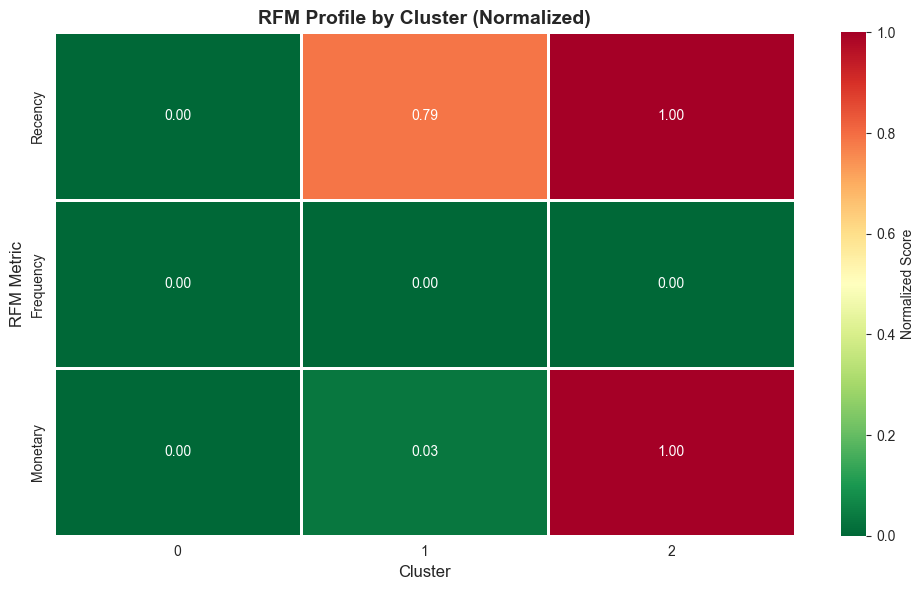

In [31]:
# Create heatmap of average RFM values per cluster
rfm_by_cluster = df_segments.groupby('kmeans_cluster')[[
    'recency_days', 'frequency_orders', 'monetary_value'
]].mean()

# Normalize for better visualization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
rfm_normalized = pd.DataFrame(
    scaler.fit_transform(rfm_by_cluster),
    index=rfm_by_cluster.index,
    columns=['Recency', 'Frequency', 'Monetary']
)

plt.figure(figsize=(10, 6))
sns.heatmap(rfm_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Normalized Score'}, linewidths=1)
plt.title('RFM Profile by Cluster (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('RFM Metric', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/rfm_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Geographic Distribution by Segment

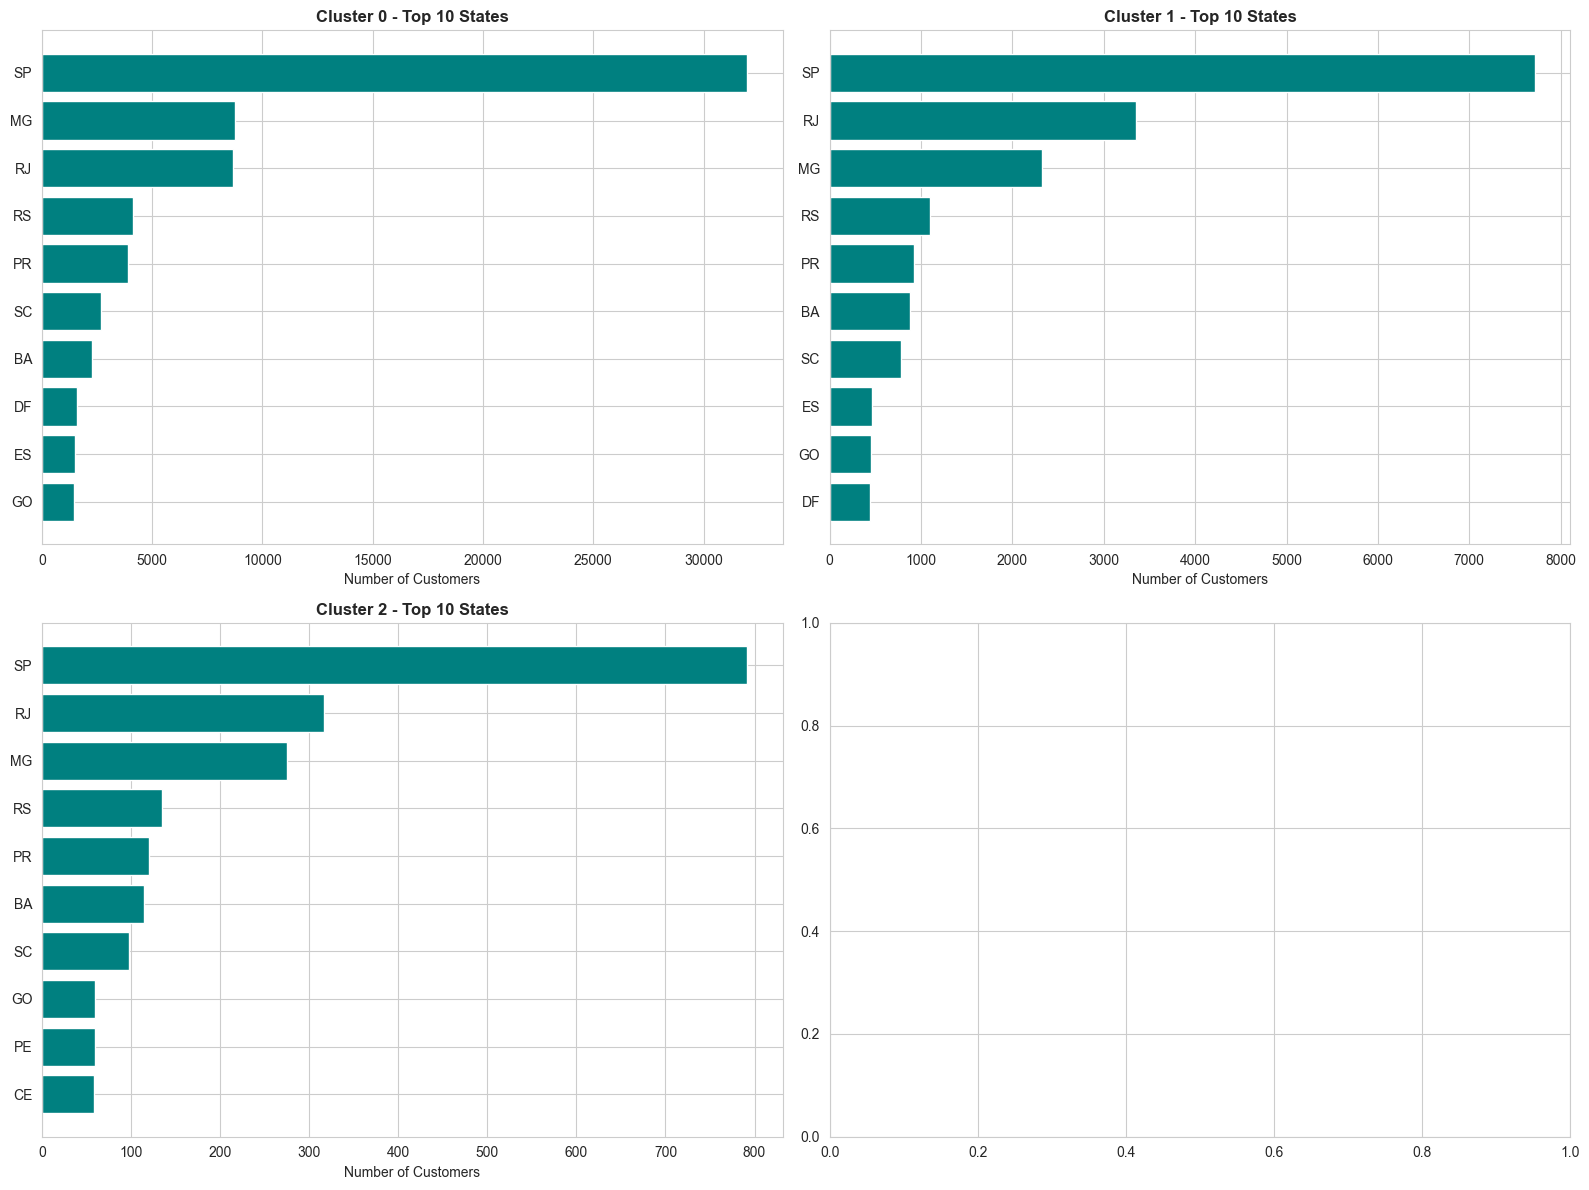

In [32]:
# Top states by cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

clusters = sorted(df_segments['kmeans_cluster'].unique())
for i, cluster in enumerate(clusters[:4]):
    if i >= len(axes):
        break
    
    cluster_data = df_segments[df_segments['kmeans_cluster'] == cluster]
    top_states = cluster_data['customer_state'].value_counts().head(10)
    
    axes[i].barh(range(len(top_states)), top_states.values, color='teal')
    axes[i].set_yticks(range(len(top_states)))
    axes[i].set_yticklabels(top_states.index)
    axes[i].set_xlabel('Number of Customers', fontsize=10)
    axes[i].set_title(f'Cluster {cluster} - Top 10 States', fontsize=12, fontweight='bold')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Customer Value Distribution

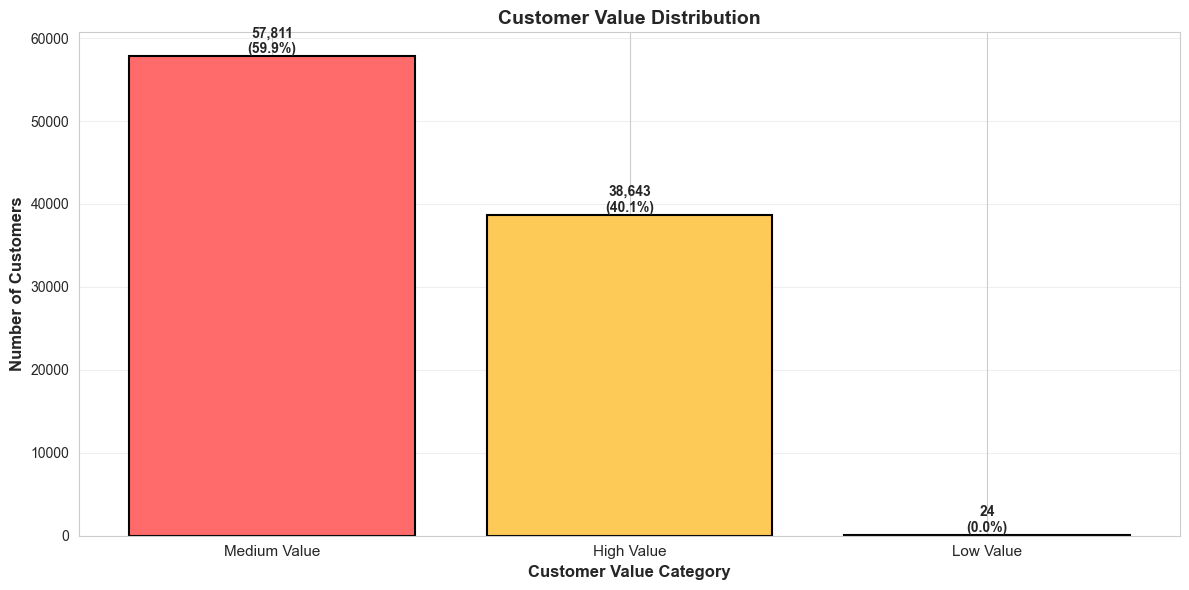

In [33]:
# Customer value category distribution
value_counts = df_segments['customer_value'].value_counts()

plt.figure(figsize=(12, 6))
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
bars = plt.bar(range(len(value_counts)), value_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.xticks(range(len(value_counts)), value_counts.index, fontsize=11)
plt.xlabel('Customer Value Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Customer Value Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(df_segments)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/customer_value_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Segment Business Insights

In [34]:
# Generate business insights
print("\n" + "="*70)
print("📊 CUSTOMER SEGMENT BUSINESS INSIGHTS")
print("="*70)

for cluster in sorted(df_segments['kmeans_cluster'].unique()):
    cluster_data = df_segments[df_segments['kmeans_cluster'] == cluster]
    
    print(f"\n🎯 Cluster {cluster}: {cluster_data['segment_label'].iloc[0]}")
    print("-" * 70)
    print(f"Size: {len(cluster_data):,} customers ({len(cluster_data)/len(df_segments)*100:.1f}%)")
    print(f"Average Recency: {cluster_data['recency_days'].mean():.0f} days")
    print(f"Average Frequency: {cluster_data['frequency_orders'].mean():.1f} orders")
    print(f"Average Monetary: ${cluster_data['monetary_value'].mean():.2f}")
    print(f"Total Revenue: ${cluster_data['monetary_value'].sum():,.2f}")
    print(f"Average Review Score: {cluster_data['avg_review_score'].mean():.2f}/5.0")
    print(f"Top State: {cluster_data['customer_state'].mode()[0]}")
    
    # Recommendations
    print("\n💡 Recommendations:")
    if cluster_data['recency_days'].mean() < 60:
        print("   ✓ Recent activity - Focus on retention")
    if cluster_data['frequency_orders'].mean() > 3:
        print("   ✓ High frequency - Offer loyalty rewards")
    if cluster_data['monetary_value'].mean() > 500:
        print("   ✓ High value - Provide VIP service")
    if cluster_data['recency_days'].mean() > 180:
        print("   ⚠️  Inactive - Launch win-back campaign")

print("\n" + "="*70)


📊 CUSTOMER SEGMENT BUSINESS INSIGHTS

🎯 Cluster 0: 😴 Lost Customers
----------------------------------------------------------------------
Size: 73,358 customers (76.0%)
Average Recency: 2890 days
Average Frequency: 1.0 orders
Average Monetary: $154.00
Total Revenue: $11,296,919.52
Average Review Score: 4.75/5.0
Top State: SP

💡 Recommendations:
   ⚠️  Inactive - Launch win-back campaign

🎯 Cluster 1: 😴 Lost Customers
----------------------------------------------------------------------
Size: 20,638 customers (21.4%)
Average Recency: 2896 days
Average Frequency: 1.0 orders
Average Monetary: $204.19
Total Revenue: $4,214,041.55
Average Review Score: 1.99/5.0
Top State: SP

💡 Recommendations:
   ⚠️  Inactive - Launch win-back campaign

🎯 Cluster 2: 😴 Lost Customers
----------------------------------------------------------------------
Size: 2,482 customers (2.6%)
Average Recency: 2897 days
Average Frequency: 1.0 orders
Average Monetary: $1718.51
Total Revenue: $4,265,342.83
Average Rev

## 11. Export Results for Dashboard

In [35]:
# Save summary statistics
summary_stats = df_segments.groupby('kmeans_cluster').agg({
    'customer_sk': 'count',
    'recency_days': 'mean',
    'frequency_orders': 'mean',
    'monetary_value': ['mean', 'sum'],
    'avg_review_score': 'mean'
}).round(2)

summary_stats.to_csv('../outputs/segment_summary.csv')
print("✅ Summary statistics saved to outputs/segment_summary.csv")

# Save segment labels
segment_labels = df_segments[['customer_sk', 'kmeans_cluster', 'segment_label']].copy()
segment_labels.to_csv('../outputs/customer_segment_labels.csv', index=False)
print("✅ Segment labels saved to outputs/customer_segment_labels.csv")

✅ Summary statistics saved to outputs/segment_summary.csv
✅ Segment labels saved to outputs/customer_segment_labels.csv


## Summary

✅ **Pipeline Completed Successfully!**

**Key Outputs:**
1. Customer segments identified using K-Means and DBSCAN
2. Optimal number of clusters determined using silhouette score
3. RFM features engineered and analyzed
4. PCA visualization created for 2D representation
5. Business insights generated for each segment
6. Results exported for dashboard integration

**Next Steps:**
- Integrate segments into dashboard for monitoring
- Create targeted marketing campaigns for each segment
- Set up alerts for customers moving between segments
- Analyze segment transitions over time